In [ ]:
!pip install ultralytics pillow

In [ ]:

from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger


def detect_and_crop_objects(image_path):
    # Load a pretrained YOLOv8 model

    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))
    # image = image_.resize((width // 2, height // 2))
    # Perform object detection
    results = model.predict(image)
    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)

        # Check if the object is fully visible
        # if x1 > 0 and y1 > 0 and x2 <= width and y2 <= height:
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2} ")

    print(f"Cropped {len(cropped_images)} fully visible objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
detect_and_crop_objects("img_test_6.webp")

In [ ]:

from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger


def detect_and_crop_objects(image_path):
    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))

    # Perform object detection
    results = model.predict(image)

    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)
        obj_width = x2 - x1
        obj_height = y2 - y1

        # Calculate the center of the object
        center_x = x1 + obj_width // 2
        center_y = y1 + obj_height // 2

        # Define the size of the cropped image
        crop_size = max(obj_width, obj_height)
        crop_x1 = max(0, center_x - crop_size // 2)
        crop_y1 = max(0, center_y - crop_size // 2)
        crop_x2 = min(image.width, center_x + crop_size // 2)
        crop_y2 = min(image.height, center_y + crop_size // 2)

        # Crop the image
        cropped_image = image.crop((crop_x1, crop_y1, crop_x2, crop_y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f}")

    print(f"Cropped {len(cropped_images)} objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
# detect_and_crop_objects("img_test_6.webp")

detect_and_crop_objects("img_test_17.jpg")

In [ ]:
detect_and_crop_objects("img_test_3.jpg")

In [ ]:
detect_and_crop_objects("img_test_6.webp")

In [ ]:
detect_and_crop_objects("img_test_16.jpg")

In [ ]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt

model = YOLO("yolov5x.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger


def detect_and_crop_objects(image_path):
    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))

    padding = 20
    cropped_image = image.crop((padding, padding, image.width - padding, image.height - padding))

    # Perform object detection
    results = model.predict(cropped_image, conf=0.8)
    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    cropped_images.append(cropped_image)
    padding = 10  # Padding in pixels

    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)

        # Expand the bounding box with padding
        x1 = max(x1 - padding, 0)
        y1 = max(y1 - padding, 0)
        x2 = min(x2 + padding, width)
        y2 = min(y2 + padding, height)

        # Crop the image
        cropped_image = image.crop((x1, y1, x2, y2))
        # cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2}")



    print(f"Cropped {len(cropped_images)} objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
detect_and_crop_objects("img_test_17.jpg")

In [51]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger

def detect_and_crop_objects(image_path):
    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))

    # Perform object detection
    results = model.predict(image, conf=0.25)

    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    #cropped_images.append(image)

    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        # Exclude humans (class ID 0)
        if cls_id == 0:
            continue

        x1, y1, x2, y2 = map(int, box)

        # Expand the bounding box with padding
        x1 = max(x1, 0)
        y1 = max(y1 , 0)
        x2 = min(x2, width)
        y2 = min(y2 , height)

        # Crop the image
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2}")

    print(f"Cropped {len(cropped_images) - 1} objects (excluding humans)!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images[1:], start=1):  # Skip the initial image
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()

# Example usage
detect_and_crop_objects("img_test_18.jpg")


0: 640x480 1 cup, 61.8ms
Speed: 4.1ms preprocess, 61.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Cropped Object 0: Class ID 41.0, Confidence 0.93 61 192 324 532
Cropped 0 objects (excluding humans)!



0: 640x640 1 book, 80.0ms
Speed: 3.5ms preprocess, 80.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Cropped Object 0: Class ID 73.0, Confidence 0.31 95 75 515 534
Cropped 1 objects (excluding humans)!


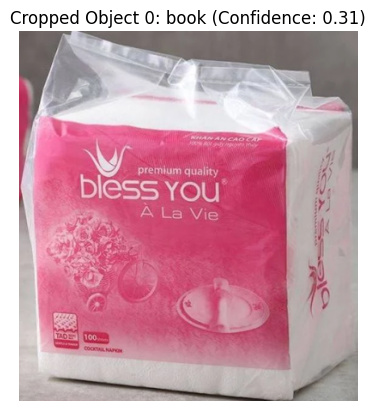

In [68]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model or "yolov8x.pt" for larger

# Define COCO class names (assuming YOLO is trained on COCO)
class_names = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck",
    "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra",
    "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
    "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "TV", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "book", "clock", "vase", "scissors", "teddy bear", "hair drier",
    "toothbrush"
]

def detect_and_crop_objects(image_path):
    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))

    # Perform object detection
    results = model.predict(image,conf=0.25)

    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects, excluding humans
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        # Exclude humans (class ID 0)
        if cls_id == 0:
            continue

        x1, y1, x2, y2 = map(int, box)

        # Crop the image
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append((cropped_image, class_ids[i], confidences[i]))  # Store image with label and confidence
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2}")

    print(f"Cropped {len(cropped_images)} objects (excluding humans)!")

    # Display cropped images with labels and scores
    for i, (cropped_image, cls_id, conf) in enumerate(cropped_images):
        label = class_names[int(cls_id)]  # Get the class name using class ID
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}: {label} (Confidence: {conf:.2f})")
        plt.axis('off')
        plt.show()

# Example usage
detect_and_crop_objects("img_test_6.webp")


0: 640x480 1 person, 1 cup, 1 tv, 1 mouse, 1 keyboard, 64.7ms
Speed: 2.1ms preprocess, 64.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Cropped Object 0: Class ID 41.0, Confidence 0.92 162 147 460 593
Cropped Object 2: Class ID 64.0, Confidence 0.77 486 459 599 595
Cropped Object 3: Class ID 66.0, Confidence 0.51 0 408 111 561
Cropped Object 4: Class ID 62.0, Confidence 0.46 0 1 599 191
Cropped 4 objects (excluding humans)!


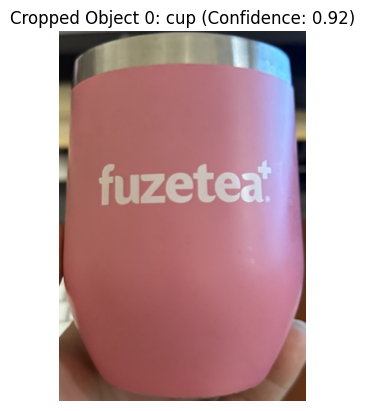

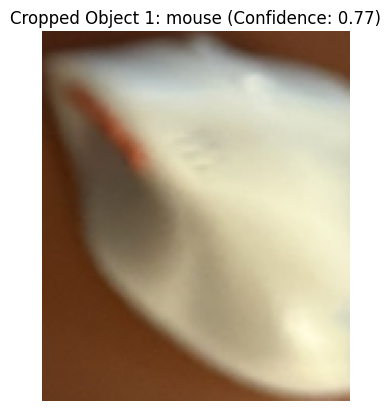

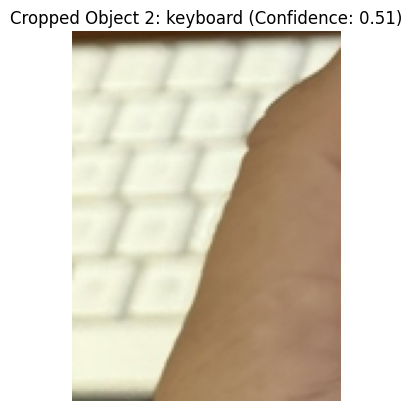

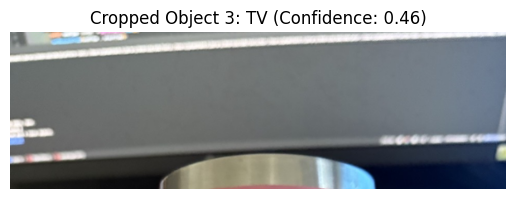

In [72]:
detect_and_crop_objects("img_test_17.jpg")